# CS514 Structural Network Analyses

This notebook contains analyses regarding:

1. centrality analysis: degree/strength and approximate betweenness
2. network topology: degree distribution, clustering, connectedness, path-length diagnostics
3. inter-community condensation graph: 43 communities as nodes
4. metadata-alignment proxy: mechanics/category overlap on behavioral edges
5. within-community core/periphery diagnostics

In [1]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 130)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUT = PROJECT_ROOT / "data" / "processed" / "cs514_network_analysis"
EDGE_PATH = OUT / "backbones" / "merged_ownership_newman_disparity_a0p025_edges.csv"
COMMUNITY_PATH = OUT / "communities" / "merged_ownership_newman_disparity_a0p025_r1p75_communities.csv"
MAPPING_PATH = OUT / "metadata" / "merged_ownership_newman_disparity_a0p025_r1p75_community_manual_mapping.csv"
DETAILS_PATH = PROJECT_ROOT / "data" / "processed" / "top_ranked_games_details" / "top_ranked_games_details_top5000_ranked_only" / "top_ranked_games_details.csv"

STRUCT_DIR = OUT / "structural_analysis"
FIG_DIR = OUT / "figures" / "structural_analysis"
STRUCT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

for path in [EDGE_PATH, COMMUNITY_PATH, MAPPING_PATH, DETAILS_PATH]:
    print(path.exists(), path)

True C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\backbones\merged_ownership_newman_disparity_a0p025_edges.csv
True C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\communities\merged_ownership_newman_disparity_a0p025_r1p75_communities.csv
True C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\metadata\merged_ownership_newman_disparity_a0p025_r1p75_community_manual_mapping.csv
True C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\top_ranked_games_details\top_ranked_games_details_top5000_ranked_only\top_ranked_games_details.csv


## Load Graph And Metadata

In [2]:
edges = pd.read_csv(EDGE_PATH)
communities = pd.read_csv(COMMUNITY_PATH)
mapping = pd.read_csv(MAPPING_PATH)
details = pd.read_csv(DETAILS_PATH)

game_meta = communities.merge(
    mapping[["community", "manual_label", "community_type", "include_in_user_profiles", "manual_meaningfulness"]],
    on="community",
    how="left",
).merge(
    details[["bgg_id", "mechanics", "categories", "average_rating", "average_weight", "owned", "year_published"]],
    on="bgg_id",
    how="left",
)

G = nx.Graph()
for row in game_meta.itertuples(index=False):
    G.add_node(
        int(row.bgg_id),
        name=row.name,
        overall_rank=int(row.overall_rank),
        community=int(row.community),
        manual_label=row.manual_label if pd.notna(row.manual_label) else "",
        community_type=row.community_type if pd.notna(row.community_type) else "",
    )

for row in edges.itertuples(index=False):
    weight = float(row.weight)
    G.add_edge(int(row.source), int(row.target), weight=weight, distance=1.0 / max(weight, 1e-12))

print(nx.info(G) if hasattr(nx, "info") else f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
print("components", nx.number_connected_components(G))
print("isolates", len(list(nx.isolates(G))))
game_meta.head()

nodes=2500, edges=214379
components 1
isolates 0


,bgg_id,community,name,overall_rank,manual_label,community_type,include_in_user_profiles,manual_meaningfulness,mechanics,categories,average_rating,average_weight,owned,year_published
0,224517,7,Brass: Birmingham,1,NaN,tiny_fragment,no,low,Chaining | End Game Bonuses | Hand Management | Income | Loans | Market | Multi-Use Cards | Network and Route Building | Owner...,Age of Reason | Economic | Industry / Manufacturing | Post-Napoleonic | Trains | Transportation,8.56572,3.8632,83197,2018
1,342942,24,Ark Nova,2,Ark Nova universal-appeal micro-cluster,bridge_singleton,no,medium,Contracts | End Game Bonuses | Events | Grid Coverage | Hand Management | Hexagon Grid | Income | Increase Value of Unchosen R...,Animals | Card Game | Environmental,8.54109,3.7975,87986,2021
2,161936,4,Pandemic Legacy: Season 1,3,Legacy + narrative mystery,shared_culture,yes,high,Action Points | Cooperative Game | Hand Management | Legacy Game | Multi-Use Cards | Point to Point Movement | Scenario / Miss...,Environmental | Medical,8.50433,2.8278,89210,2015
3,174430,12,Gloomhaven,4,Dungeon crawl / cooperative campaign adventure,taste_specialist,yes,high,Action Queue | Action Retrieval | Campaign / Battle Card Driven | Card Play Conflict Resolution | Communication Limits | Coope...,Adventure | Exploration | Fantasy | Fighting | Miniatures,8.54120,3.9179,104327,2017
4,397598,19,Dune: Imperium – Uprising,5,Recent releases / new-hotness cluster,temporal_artifact,no,medium,"Automatic Resource Growth | Card Play Conflict Resolution | Contracts | Deck, Bag, and Pool Building | Delayed Purchase | Forc...",Movies / TV / Radio theme | Novel-based | Science Fiction,8.70166,3.5241,27702,2023


## 1. Centrality Analysis

This section formalizes the bridge-game discussion. Instead of relying only on manual labels, we compute network centrality.

Because exact weighted betweenness can be slow on a 2,500-node dense graph, we compute approximate betweenness using a fixed sample of source nodes. This is sufficient for ranking bridge candidates for interpretation.

In [3]:
degree = dict(G.degree())
strength = dict(G.degree(weight="weight"))
weighted_clustering = nx.clustering(G, weight="weight")

# Approximate betweenness. Increase k for a slower but more precise ranking.
BETWEENNESS_K = min(500, G.number_of_nodes())
betweenness = nx.betweenness_centrality(
    G,
    k=BETWEENNESS_K,
    normalized=True,
    weight="distance",
    seed=514,
)

centrality = game_meta[[
    "bgg_id", "name", "overall_rank", "community", "manual_label", "community_type", "average_rating", "average_weight", "owned", "year_published"
]].copy()
centrality["degree"] = centrality["bgg_id"].map(degree).fillna(0).astype(int)
centrality["weighted_degree_strength"] = centrality["bgg_id"].map(strength).fillna(0.0)
centrality["betweenness"] = centrality["bgg_id"].map(betweenness).fillna(0.0)
centrality["weighted_clustering"] = centrality["bgg_id"].map(weighted_clustering).fillna(0.0)
centrality["degree_rank"] = centrality["degree"].rank(ascending=False, method="min").astype(int)
centrality["strength_rank"] = centrality["weighted_degree_strength"].rank(ascending=False, method="min").astype(int)
centrality["betweenness_rank"] = centrality["betweenness"].rank(ascending=False, method="min").astype(int)
centrality.to_csv(STRUCT_DIR / "game_centrality_alpha0p025_gamma1p75.csv", index=False)

centrality.sort_values("betweenness", ascending=False).head(25)

,bgg_id,name,overall_rank,community,manual_label,community_type,average_rating,average_weight,owned,year_published,degree,weighted_degree_strength,betweenness,weighted_clustering,degree_rank,strength_rank,betweenness_rank
8,167791,Terraforming Mars,9,0,Terraforming Mars universal-appeal micro-cluster,bridge_singleton,8.33884,3.2704,158835,2016,2480,2247.921772,0.229668,0.006384,2,2,1
23,173346,7 Wonders Duel,24,33,NaN,tiny_fragment,8.07792,2.2275,183398,2015,2455,2268.689634,0.190213,0.006539,5,1,2
95,230802,Azul,96,14,Abstract tile-placement puzzle bridge,bridge_cluster,7.71651,1.7748,182210,2017,2462,2214.698541,0.172228,0.006374,3,3,3
238,822,Carcassonne,239,38,Racing / sports / route bridge,bridge_cluster,7.41623,1.8853,222503,2000,2486,2131.592839,0.165029,0.006100,1,4,4
37,266192,Wingspan,38,34,Licensed family/fandom games,franchise_series,8.00113,2.4798,179326,2019,2364,2109.415220,0.144652,0.006624,9,5,5
160,178900,Codenames,161,37,Escape-room / Unlock series cluster,franchise_series,7.52534,1.2558,179294,2015,2462,2089.049035,0.132067,0.006112,3,6,6
13,12333,Twilight Struggle,14,20,Historical wargames + conflict strategy,taste_specialist,8.22934,3.6146,73380,2005,1458,1046.554885,0.089924,0.008376,47,39,7
169,30549,Pandemic,170,26,Pandemic system cluster,franchise_series,7.51418,2.3941,225180,2008,2455,1941.197219,0.080371,0.005841,5,7,8
1,342942,Ark Nova,2,24,Ark Nova universal-appeal micro-cluster,bridge_singleton,8.54109,3.7975,87986,2021,2243,1826.965919,0.069230,0.006527,13,10,9
605,13,Catan,615,11,KeyForge / Catan gateway-franchise cluster,franchise_series,7.09131,2.2827,239038,1995,2446,1910.681497,0.056086,0.005839,7,8,10


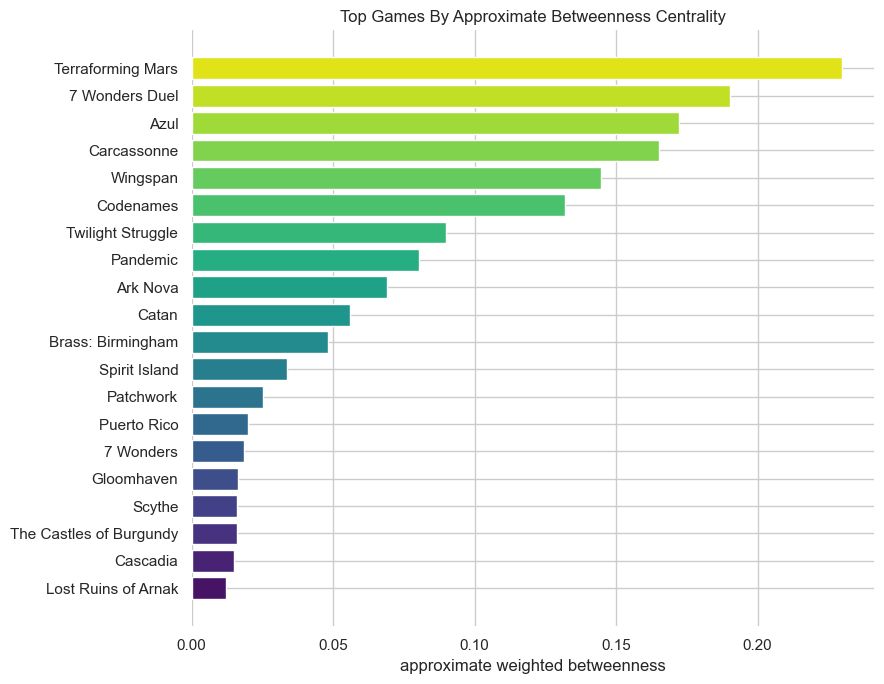

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
top_b = centrality.sort_values("betweenness", ascending=False).head(20).sort_values("betweenness")
colors = sns.color_palette("viridis", n_colors=len(top_b))
ax.barh(top_b["name"], top_b["betweenness"], color=colors)
ax.set_title("Top Games By Approximate Betweenness Centrality")
ax.set_xlabel("approximate weighted betweenness")
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "top20_betweenness_games.png", dpi=220, bbox_inches="tight")
plt.show()

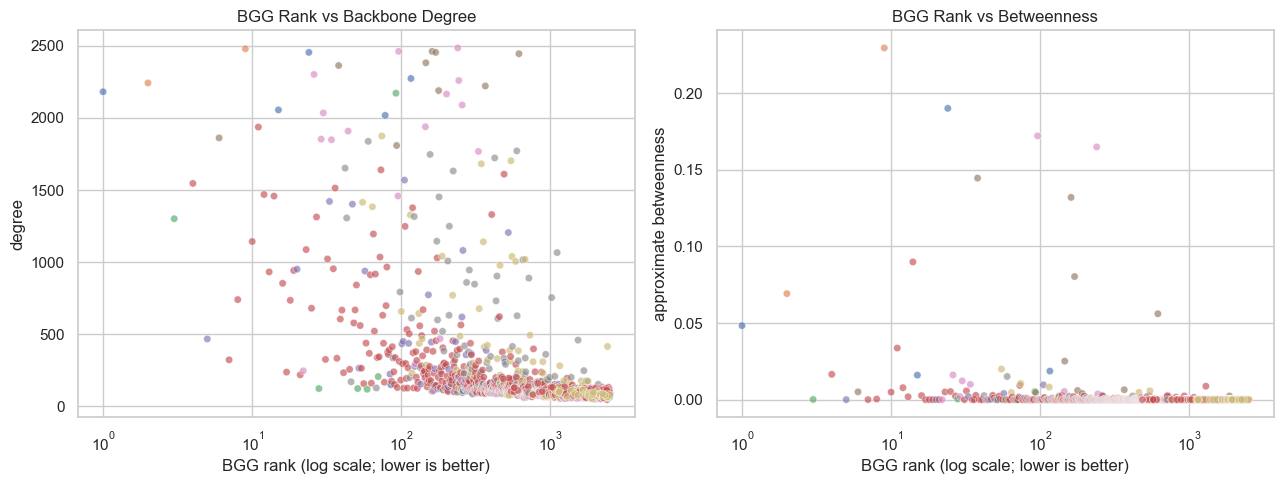

,overall_rank,degree,weighted_degree_strength,betweenness,owned
overall_rank,1.000,-0.619,-0.824,-0.354,-0.744
degree,-0.619,1.000,0.792,0.385,0.598
weighted_degree_strength,-0.824,0.792,1.000,0.384,0.867
betweenness,-0.354,0.385,0.384,1.000,0.370
owned,-0.744,0.598,0.867,0.370,1.000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=centrality, x="overall_rank", y="degree", hue="community_type", s=28, alpha=0.65, ax=axes[0], legend=False)
axes[0].set_xscale("log")
axes[0].set_title("BGG Rank vs Backbone Degree")
axes[0].set_xlabel("BGG rank (log scale; lower is better)")
axes[0].set_ylabel("degree")

sns.scatterplot(data=centrality, x="overall_rank", y="betweenness", hue="community_type", s=28, alpha=0.65, ax=axes[1], legend=False)
axes[1].set_xscale("log")
axes[1].set_title("BGG Rank vs Betweenness")
axes[1].set_xlabel("BGG rank (log scale; lower is better)")
axes[1].set_ylabel("approximate betweenness")

fig.tight_layout()
fig.savefig(FIG_DIR / "rank_vs_degree_betweenness.png", dpi=220, bbox_inches="tight")
plt.show()

centrality[["overall_rank", "degree", "weighted_degree_strength", "betweenness", "owned"]].corr(method="spearman").round(3)

## 2. Network Topology Characterization

This section describes what kind of graph the validated backbone is before interpreting communities.

In [6]:
component_sizes = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
degrees = np.array([d for _, d in G.degree()])
strengths = np.array([d for _, d in G.degree(weight="weight")])

topology = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "density": nx.density(G),
    "components": nx.number_connected_components(G),
    "giant_component_nodes": component_sizes[0],
    "giant_component_fraction": component_sizes[0] / G.number_of_nodes(),
    "isolates": len(list(nx.isolates(G))),
    "mean_degree": float(degrees.mean()),
    "median_degree": float(np.median(degrees)),
    "max_degree": int(degrees.max()),
    "mean_strength": float(strengths.mean()),
    "median_strength": float(np.median(strengths)),
    "max_strength": float(strengths.max()),
    "average_clustering_unweighted": nx.average_clustering(G),
    "average_clustering_weighted": nx.average_clustering(G, weight="weight"),
    "transitivity": nx.transitivity(G),
    "er_random_expected_clustering_p": nx.density(G),
}

if nx.is_connected(G):
    topology["average_shortest_path_unweighted"] = nx.average_shortest_path_length(G)
    topology["diameter_unweighted"] = nx.diameter(G)
else:
    giant_nodes = max(nx.connected_components(G), key=len)
    H = G.subgraph(giant_nodes).copy()
    topology["average_shortest_path_unweighted_giant"] = nx.average_shortest_path_length(H)
    topology["diameter_unweighted_giant"] = nx.diameter(H)

topology_df = pd.DataFrame([topology]).T.reset_index()
topology_df.columns = ["metric", "value"]
topology_df.to_csv(STRUCT_DIR / "network_topology_alpha0p025_gamma1p75.csv", index=False)
topology_df

,metric,value
0,nodes,2500.000000
1,edges,214379.000000
2,density,0.068629
3,components,1.000000
4,giant_component_nodes,2500.000000
5,giant_component_fraction,1.000000
6,isolates,0.000000
7,mean_degree,171.503200
8,median_degree,94.000000
9,max_degree,2486.000000


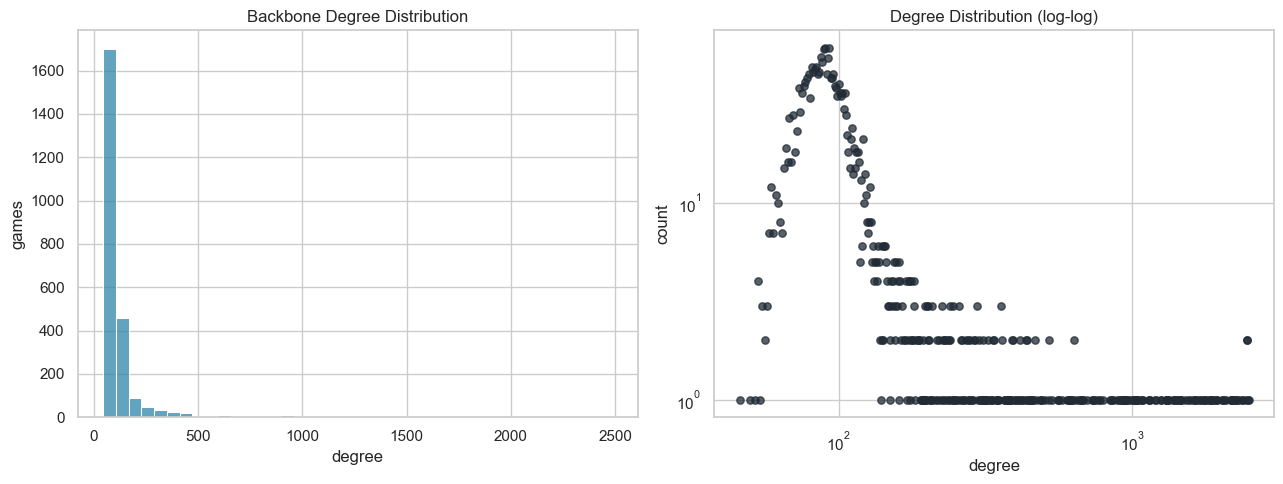

,degree
count,2500.00000
mean,171.50320
std,300.98385
min,46.00000
10%,73.00000
25%,82.00000
50%,94.00000
75%,116.00000
90%,233.20000
95%,521.00000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(degrees, bins=40, ax=axes[0], color="#2E86AB")
axes[0].set_title("Backbone Degree Distribution")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("games")

degree_counts = pd.Series(degrees).value_counts().sort_index()
axes[1].scatter(degree_counts.index, degree_counts.values, s=28, alpha=0.75, color="#212B36")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Degree Distribution (log-log)")
axes[1].set_xlabel("degree")
axes[1].set_ylabel("count")

fig.tight_layout()
fig.savefig(FIG_DIR / "degree_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

pd.Series(degrees).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("degree")

## 3. Inter-Community Condensation Graph

The condensation graph compresses the 2,500-game graph into a 43-node community-level graph. Nodes are communities; edges are total co-ownership backbone weight between communities.

This tells us which taste/behavioral communities are structurally adjacent.

In [8]:
comm_lookup = game_meta.set_index("bgg_id")["community"].astype(int).to_dict()
label_lookup = mapping.set_index("community")["manual_label"].fillna("").to_dict()
type_lookup = mapping.set_index("community")["community_type"].fillna("").to_dict()
size_lookup = mapping.set_index("community")["size"].astype(int).to_dict()

comm_edges = {}
internal_weight = {int(c): 0.0 for c in mapping["community"]}
external_weight = {int(c): 0.0 for c in mapping["community"]}

for u, v, data in G.edges(data=True):
    cu, cv = comm_lookup[u], comm_lookup[v]
    w = float(data["weight"])
    if cu == cv:
        internal_weight[cu] = internal_weight.get(cu, 0.0) + w
    else:
        key = tuple(sorted((cu, cv)))
        entry = comm_edges.setdefault(key, {"edge_count": 0, "weight": 0.0})
        entry["edge_count"] += 1
        entry["weight"] += w
        external_weight[cu] = external_weight.get(cu, 0.0) + w
        external_weight[cv] = external_weight.get(cv, 0.0) + w

C = nx.Graph()
for c in mapping["community"].astype(int):
    total = internal_weight.get(c, 0.0) + external_weight.get(c, 0.0)
    C.add_node(
        c,
        label=label_lookup.get(c, ""),
        community_type=type_lookup.get(c, ""),
        size=size_lookup.get(c, 0),
        internal_weight=internal_weight.get(c, 0.0),
        external_weight=external_weight.get(c, 0.0),
        internal_weight_share=internal_weight.get(c, 0.0) / total if total else 0.0,
    )

for (cu, cv), attrs in comm_edges.items():
    C.add_edge(cu, cv, weight=attrs["weight"], edge_count=attrs["edge_count"])

cond_nodes = pd.DataFrame([
    {"community": n, **data, "community_degree": C.degree(n), "community_strength": C.degree(n, weight="weight")}
    for n, data in C.nodes(data=True)
]).sort_values("community_strength", ascending=False)

cond_edges = pd.DataFrame([
    {
        "community_a": u,
        "community_b": v,
        "label_a": C.nodes[u]["label"],
        "label_b": C.nodes[v]["label"],
        "edge_count": data["edge_count"],
        "weight": data["weight"],
    }
    for u, v, data in C.edges(data=True)
]).sort_values("weight", ascending=False)

cond_nodes.to_csv(STRUCT_DIR / "community_condensation_nodes.csv", index=False)
cond_edges.to_csv(STRUCT_DIR / "community_condensation_edges.csv", index=False)

display(cond_nodes.head(15))
display(cond_edges.head(20))

,community,label,community_type,size,internal_weight,external_weight,internal_weight_share,community_degree,community_strength
0,10,BGG Golden Age canon,temporal_canon,338,4029.336768,16677.336112,0.194591,42,16677.336112
3,19,Recent releases / new-hotness cluster,temporal_artifact,231,2095.479040,14094.791377,0.129428,42,14094.791377
4,2,Current heavy euro engine builders,taste_specialist,207,3012.761863,13792.477680,0.179275,42,13792.477680
1,9,Amerithrash / miniatures / LCG,taste_specialist,251,2211.823624,13001.783436,0.145385,42,13001.783436
6,25,Party / family / social deduction,taste_cross_over,177,1241.209756,12705.959835,0.088994,42,12705.959835
2,12,Dungeon crawl / cooperative campaign adventure,taste_specialist,231,1941.680207,12185.530596,0.137443,42,12185.530596
8,8,Medium worker-placement euros,taste_specialist,166,1300.384610,11152.378145,0.104425,42,11152.378145
7,13,Puzzle / nature tableau builders,taste_cross_over,168,951.460744,10913.125962,0.080193,42,10913.125962
9,35,Cooperative trick-taking + deduction,taste_cross_over,100,475.602854,7911.197120,0.056709,42,7911.197120
5,20,Historical wargames + conflict strategy,taste_specialist,198,1740.179404,7435.753892,0.189646,42,7435.753892


,community_a,community_b,label_a,label_b,edge_count,weight
11,10,8,BGG Golden Age canon,Medium worker-placement euros,4110,1871.719891
129,19,2,Recent releases / new-hotness cluster,Current heavy euro engine builders,3475,1777.455243
6,10,9,BGG Golden Age canon,Amerithrash / miniatures / LCG,3956,1637.461790
35,10,25,BGG Golden Age canon,Party / family / social deduction,3232,1629.422713
7,10,20,BGG Golden Age canon,Historical wargames + conflict strategy,4473,1621.048801
141,19,13,Recent releases / new-hotness cluster,Puzzle / nature tableau builders,3476,1617.493459
169,2,8,Current heavy euro engine builders,Medium worker-placement euros,2759,1609.251763
45,9,12,Amerithrash / miniatures / LCG,Dungeon crawl / cooperative campaign adventure,3743,1540.922218
75,9,25,Amerithrash / miniatures / LCG,Party / family / social deduction,3120,1441.750288
86,12,19,Dungeon crawl / cooperative campaign adventure,Recent releases / new-hotness cluster,2973,1344.188995


## 4. Metadata Alignment Proxy

BGG mechanics and categories are multi-label, so standard single-label assortativity is not a perfect fit. Here we use an edge-level metadata-overlap proxy:

- For each behavioral edge, compute Jaccard overlap of mechanics and categories.
- Compare observed edge overlap against random game pairs.

If behavioral edges have higher metadata overlap than random pairs, metadata helps explain co-ownership. If overlap is low, behavior diverges from metadata.

In [10]:
def parse_tags(value):
    if pd.isna(value):
        return set()
    return {part.strip() for part in str(value).split("|") if part.strip()}

tag_meta = game_meta[["bgg_id", "mechanics", "categories"]].copy()
mechanics_by_game = tag_meta.set_index("bgg_id")["mechanics"].map(parse_tags).to_dict()
categories_by_game = tag_meta.set_index("bgg_id")["categories"].map(parse_tags).to_dict()

def jaccard(a, b):
    if not a and not b:
        return np.nan
    union = a | b
    return len(a & b) / len(union) if union else np.nan

edge_overlap_rows = []
for u, v, data in G.edges(data=True):
    mech_j = jaccard(mechanics_by_game.get(u, set()), mechanics_by_game.get(v, set()))
    cat_j = jaccard(categories_by_game.get(u, set()), categories_by_game.get(v, set()))
    edge_overlap_rows.append({
        "source": u,
        "target": v,
        "weight": data["weight"],
        "mechanics_jaccard": mech_j,
        "categories_jaccard": cat_j,
        "shares_any_mechanic": mech_j > 0 if not pd.isna(mech_j) else False,
        "shares_any_category": cat_j > 0 if not pd.isna(cat_j) else False,
    })
edge_overlap = pd.DataFrame(edge_overlap_rows)
edge_overlap.to_csv(STRUCT_DIR / "edge_metadata_overlap.csv", index=False)

rng = np.random.default_rng(514)
nodes = np.array(list(G.nodes()))
sample_n = min(len(edge_overlap), 200000)
random_pairs = rng.choice(nodes, size=(sample_n, 2), replace=True)
random_rows = []
for u, v in random_pairs:
    if u == v:
        continue
    mech_j = jaccard(mechanics_by_game.get(int(u), set()), mechanics_by_game.get(int(v), set()))
    cat_j = jaccard(categories_by_game.get(int(u), set()), categories_by_game.get(int(v), set()))
    random_rows.append({
        "mechanics_jaccard": mech_j,
        "categories_jaccard": cat_j,
        "shares_any_mechanic": mech_j > 0 if not pd.isna(mech_j) else False,
        "shares_any_category": cat_j > 0 if not pd.isna(cat_j) else False,
    })
random_overlap = pd.DataFrame(random_rows)

metadata_alignment = pd.DataFrame([
    {
        "pair_set": "behavioral_backbone_edges",
        "n_pairs": len(edge_overlap),
        "mean_mechanics_jaccard": edge_overlap["mechanics_jaccard"].mean(),
        "mean_categories_jaccard": edge_overlap["categories_jaccard"].mean(),
        "share_any_mechanic": edge_overlap["shares_any_mechanic"].mean(),
        "share_any_category": edge_overlap["shares_any_category"].mean(),
    },
    {
        "pair_set": "random_game_pairs",
        "n_pairs": len(random_overlap),
        "mean_mechanics_jaccard": random_overlap["mechanics_jaccard"].mean(),
        "mean_categories_jaccard": random_overlap["categories_jaccard"].mean(),
        "share_any_mechanic": random_overlap["shares_any_mechanic"].mean(),
        "share_any_category": random_overlap["shares_any_category"].mean(),
    },
])
metadata_alignment.to_csv(STRUCT_DIR / "metadata_alignment_proxy.csv", index=False)
metadata_alignment.round(4)

,pair_set,n_pairs,mean_mechanics_jaccard,mean_categories_jaccard,share_any_mechanic,share_any_category
0,behavioral_backbone_edges,214379,0.0910,0.0982,0.6433,0.3795
1,random_game_pairs,199932,0.0653,0.0576,0.4901,0.2451


## 5. Within-Community Core And Periphery

Within each detected community, we can ask which games are structurally central to that community and which are peripheral/boundary cases.

- `internal_strength`: total edge weight to games in the same community
- `external_strength`: total edge weight to games in other communities
- `internal_strength_share`: internal / (internal + external)

High internal strength and high internal share suggest a community core. Low internal share suggests a boundary or bridge game.

In [11]:
internal = {n: 0.0 for n in G.nodes()}
external = {n: 0.0 for n in G.nodes()}
internal_degree = {n: 0 for n in G.nodes()}
external_degree = {n: 0 for n in G.nodes()}

for u, v, data in G.edges(data=True):
    w = float(data["weight"])
    if comm_lookup[u] == comm_lookup[v]:
        internal[u] += w
        internal[v] += w
        internal_degree[u] += 1
        internal_degree[v] += 1
    else:
        external[u] += w
        external[v] += w
        external_degree[u] += 1
        external_degree[v] += 1

core = centrality.copy()
core["internal_degree"] = core["bgg_id"].map(internal_degree).fillna(0).astype(int)
core["external_degree"] = core["bgg_id"].map(external_degree).fillna(0).astype(int)
core["internal_strength"] = core["bgg_id"].map(internal).fillna(0.0)
core["external_strength"] = core["bgg_id"].map(external).fillna(0.0)
core["internal_strength_share"] = core["internal_strength"] / (core["internal_strength"] + core["external_strength"]).replace(0, np.nan)
core["community_internal_strength_rank"] = core.groupby("community")["internal_strength"].rank(ascending=False, method="first").astype(int)
core.to_csv(STRUCT_DIR / "within_community_core_periphery.csv", index=False)

core_examples = core.sort_values(["community", "community_internal_strength_rank"]).groupby("community").head(5)
core_examples[["community", "manual_label", "name", "overall_rank", "internal_degree", "external_degree", "internal_strength", "external_strength", "internal_strength_share"]].head(40)

,community,manual_label,name,overall_rank,internal_degree,external_degree,internal_strength,external_strength,internal_strength_share
8,0,Terraforming Mars universal-appeal micro-cluster,Terraforming Mars,9,5,2475,2.819191,2245.102581,0.001254
935,0,Terraforming Mars universal-appeal micro-cluster,Abomination: The Heir of Frankenstein,962,1,64,0.692114,21.624528,0.031013
990,0,Terraforming Mars universal-appeal micro-cluster,Outlive,1022,1,74,0.667689,24.790258,0.026227
1974,0,Terraforming Mars universal-appeal micro-cluster,New Bedford,2221,1,61,0.612024,10.979223,0.052801
1894,0,Terraforming Mars universal-appeal micro-cluster,Village Rails,2114,1,69,0.428219,17.040572,0.024513
29,1,Thematic adventure / licensed bridge cluster,Lost Ruins of Arnak,30,9,2026,4.919594,1558.198926,0.003147
1256,1,Thematic adventure / licensed bridge cluster,Star Wars: Jabba's Palace – A Love Letter Game,1327,3,103,1.694031,55.700079,0.029516
1558,1,Thematic adventure / licensed bridge cluster,Infinity Gauntlet: A Love Letter Game,1685,2,87,1.118342,39.896610,0.027267
624,1,Thematic adventure / licensed bridge cluster,Star Wars: Unlimited,634,2,88,0.923023,29.330717,0.030509
810,1,Thematic adventure / licensed bridge cluster,AuZtralia,830,1,72,0.635920,30.820459,0.020216


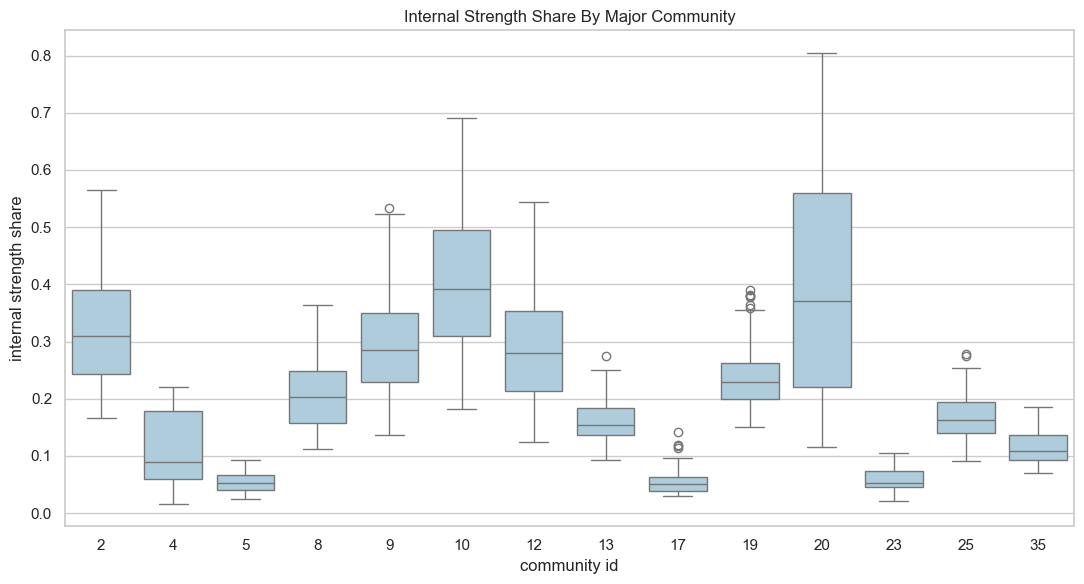

,community,manual_label,community_type,size,median_internal_strength_share,mean_internal_strength_share,median_internal_degree,median_external_degree
8,10,BGG Golden Age canon,temporal_canon,338,0.392054,0.401379,39.0,51.0
18,20,Historical wargames + conflict strategy,taste_specialist,198,0.370692,0.402990,52.0,66.0
2,2,Current heavy euro engine builders,taste_specialist,207,0.308919,0.316648,36.0,67.0
14,16,Unmatched / skirmish series cluster,franchise_series,20,0.291276,0.260587,18.0,77.0
7,9,Amerithrash / miniatures / LCG,taste_specialist,251,0.284572,0.296091,32.0,69.0
10,12,Dungeon crawl / cooperative campaign adventure,taste_specialist,231,0.280766,0.287340,30.0,68.0
17,19,Recent releases / new-hotness cluster,temporal_artifact,231,0.229756,0.236318,23.0,72.0
6,8,Medium worker-placement euros,taste_specialist,166,0.202193,0.208610,18.0,66.0
23,25,Party / family / social deduction,taste_cross_over,177,0.162275,0.166321,17.0,78.0
11,13,Puzzle / nature tableau builders,taste_cross_over,168,0.154803,0.163326,15.0,73.0


In [12]:
major_communities = mapping.sort_values("size", ascending=False).head(14)["community"].astype(int).tolist()
major_core = core[core["community"].isin(major_communities)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=major_core, x="community", y="internal_strength_share", color="#A6CEE3", ax=ax)
ax.set_title("Internal Strength Share By Major Community")
ax.set_xlabel("community id")
ax.set_ylabel("internal strength share")
fig.tight_layout()
fig.savefig(FIG_DIR / "internal_strength_share_by_community.png", dpi=220, bbox_inches="tight")
plt.show()

community_core_summary = core.groupby(["community", "manual_label", "community_type"]).agg(
    size=("bgg_id", "count"),
    median_internal_strength_share=("internal_strength_share", "median"),
    mean_internal_strength_share=("internal_strength_share", "mean"),
    median_internal_degree=("internal_degree", "median"),
    median_external_degree=("external_degree", "median"),
).reset_index().sort_values("median_internal_strength_share", ascending=False)
community_core_summary.to_csv(STRUCT_DIR / "community_core_periphery_summary.csv", index=False)
community_core_summary.head(20)

## Takeaways

1. Centrality turns bridge-game interpretation into a formal network claim.
2. Degree distribution and clustering characterize the backbone before community detection.
3. The condensation graph shows relationships among taste communities at a higher scale.
4. Metadata-overlap checks formalize the question of whether behavior aligns with BGG taxonomy.
5. Core/periphery scores distinguish community anchors from boundary games.
